## Cleaning and Splitting Dataset

In [10]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import time
import seaborn as sns
import numpy as np
import re
import os

In [11]:
df = pd.read_csv('autism.csv')

In [12]:
states = df['State'].unique()

In [15]:
df = df[df['State'] != 'Total']

# Define the folder name
folder_name = "States"

# Create the folder if it doesn't already exist
if not os.path.exists(folder_name):
    os.makedirs(folder_name)

# Get the unique states (now excluding 'Total')
states = df['State'].unique()

# Iterate through each state and save a separate CSV file
for state in states:
    state_df = df[df['State'] == state]
    safe_state_name = state.replace(' ', '_')
    file_path = os.path.join(folder_name, f"autism_{safe_state_name}.csv")
    state_df.to_csv(file_path, index=False)

print(f"Successfully created {len(states)} individual state datasets in the '{folder_name}' folder (excluding 'Total').")

Successfully created 52 individual state datasets in the 'States' folder (excluding 'Total').


In [16]:
# Define the folder where the files are stored
folder_name = "States"

# 1. Get all the CSV files from the "States" folder
files = [f for f in os.listdir(folder_name) if f.startswith("autism_") and f.endswith(".csv")]

# 2. Iterate through each file and create a new variable
for file in files:
    # Extract the state name from the filename to use as the variable name
    # Example: "autism_Alabama.csv" becomes "Alabama"
    # Example: "autism_New_York.csv" becomes "New_York"
    var_name = file.replace("autism_", "").replace(".csv", "")
    
    # Path to the file
    file_path = os.path.join(folder_name, file)
    
    # 3. Use globals() to dynamically create a variable for each state
    # This is equivalent to: Alabama = pd.read_csv('States/autism_Alabama.csv')
    globals()[var_name] = pd.read_csv(file_path)

# --- Verification ---
# You can now call the variables directly by the state name:
print("Preview of Alabama variable:")
print(Alabama.head())

print("\nPreview of New_York variable:")
print(New_York.head())

Preview of Alabama variable:
     State  Denominator  Prevalence Estimates per 1,000 Children  Lower CI  \
0  Alabama      35472.0                                      3.3       2.7   
1  Alabama      11676.0                                      4.6       3.5   
2  Alabama      35126.0                                      6.0       5.3   
3  Alabama      36566.0                                      4.8       4.1   
4  Alabama      21833.0                                      5.7       4.8   

   Upper CI Prevalence Range Show Lower and Upper CI  Year       Data Set  
0       3.9              <10                     Yes  2002  ADDM Network*  
1       6.0              <10                     Yes  2004  ADDM Network*  
2       6.9              <10                     Yes  2006  ADDM Network*  
3       5.5              <10                     Yes  2008  ADDM Network*  
4       6.8              <10                     Yes  2010  ADDM Network*  

Preview of New_York variable:
      State  De

In [1]:
New_Hampshire.head()

NameError: name 'New_Hampshire' is not defined

## Line Graphing

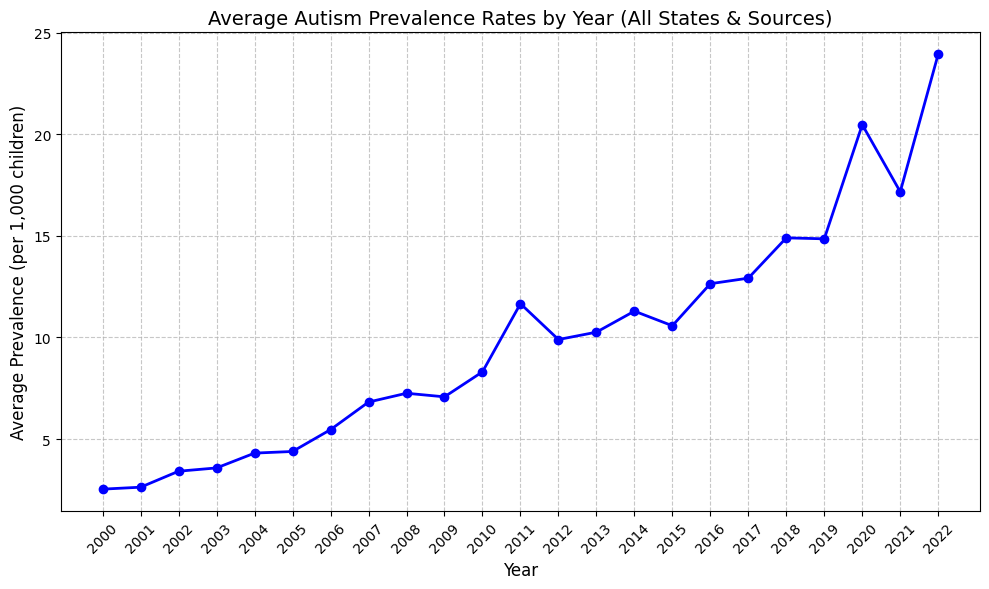

In [8]:
df_no_total = df[df['State'] != 'Total']

# Group by 'Year' and calculate the mean prevalence
yearly_avg = df_no_total.groupby('Year')['Prevalence Estimates per 1,000 Children'].mean()

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(yearly_avg.index, yearly_avg.values, marker='o', linestyle='-', color='b', linewidth=2)

# Set labels and title
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Prevalence (per 1,000 children)', fontsize=12)
plt.title('Average Autism Prevalence Rates by Year (All States & Sources)', fontsize=14)

# Formatting
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(yearly_avg.index, rotation=45)
plt.tight_layout()

# Save the plot
plt.savefig('autism_trend_yearly.png')
plt.show()

# Optional: Save the trend data to a CSV for reference
yearly_avg.to_csv('yearly_autism_rates.csv')

Enter the name of the state you want to analyze:  Virginia


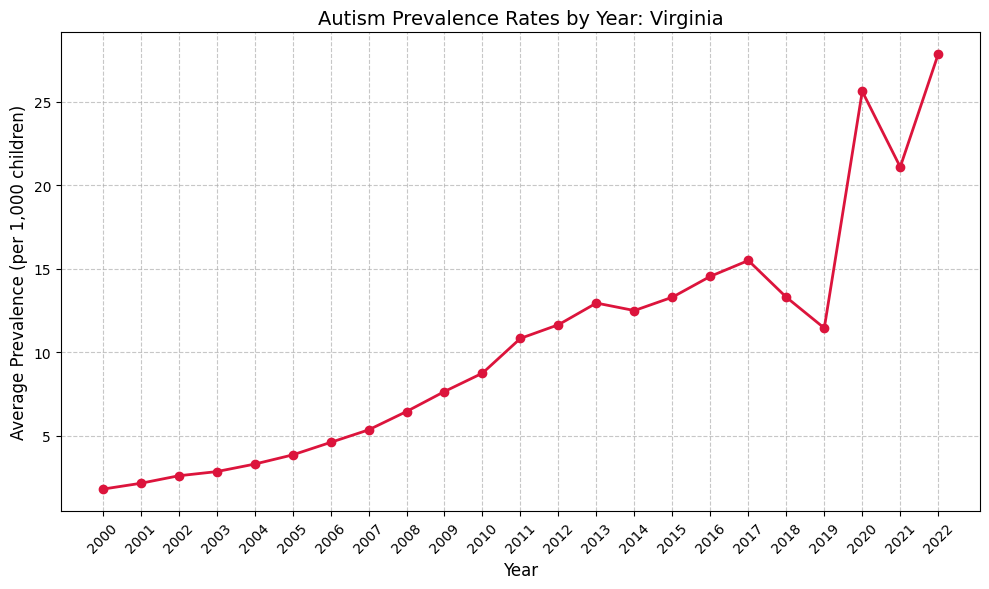

Graph successfully generated and saved as autism_trend_virginia.png


In [20]:
user_input = input("Enter the name of the state you want to analyze: ")

# Format the input to match your file naming convention (e.g., "New York" -> "New_York")
state_name = user_input.strip().title().replace(" ", "_")
file_path = os.path.join("States", f"autism_{state_name}.csv")

# 2. Load the specific state dataframe
if os.path.exists(file_path):
    state_df = pd.read_csv(file_path)

    # 3. Group by 'Year' and calculate the mean prevalence
    state_yearly = state_df.groupby('Year')['Prevalence Estimates per 1,000 Children'].mean()

    # 4. Create the plot
    plt.figure(figsize=(10, 6))
    plt.plot(state_yearly.index, state_yearly.values, marker='o', linestyle='-', color='crimson', linewidth=2)

    # Set labels and title (using the user's original input for the title looks cleaner)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Average Prevalence (per 1,000 children)', fontsize=12)
    plt.title(f'Autism Prevalence Rates by Year: {user_input.title()}', fontsize=14)

    # Formatting
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xticks(state_yearly.index, rotation=45)
    plt.tight_layout()

    # 5. Save and show
    save_name = f'autism_trend_{state_name.lower()}.png'
    plt.savefig(save_name)
    plt.show()
    
    print(f"Graph successfully generated and saved as {save_name}")
else:
    print(f"Error: Could not find a file for '{user_input}'.")
    print(f"Expected path: {file_path}")
    print("Make sure you typed the name correctly and that the splitting script has been run.")

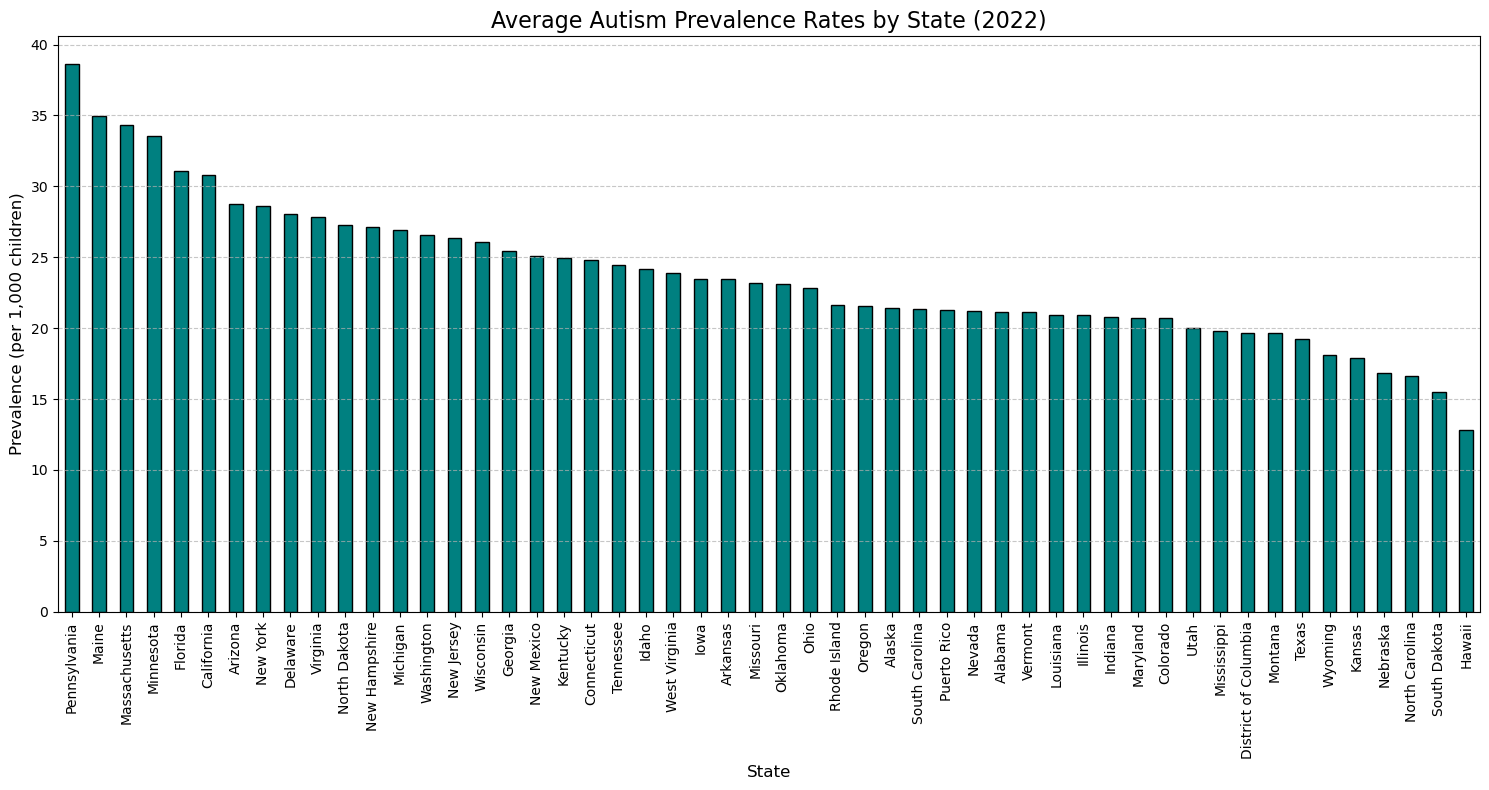

In [15]:
df_2022 = df[(df['Year'] == 2022) & (df['State'] != 'Total')]

# Group by state to get a single average prevalence rate per state
state_rates_2022 = df_2022.groupby('State')['Prevalence Estimates per 1,000 Children'].mean()

# Sort states by prevalence rate for better readability (descending order)
state_rates_2022_sorted = state_rates_2022.sort_values(ascending=False)

# Create the bar chart
plt.figure(figsize=(15, 8))
state_rates_2022_sorted.plot(kind='bar', color='teal', edgecolor='black')

# Add labels and title
plt.title('Average Autism Prevalence Rates by State (2022)', fontsize=16)
plt.xlabel('State', fontsize=12)
plt.ylabel('Prevalence (per 1,000 children)', fontsize=12)

# Formatting: Rotate x-axis labels to prevent overlap and add a grid
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save the plot
plt.savefig('autism_bar_chart_2022.png')
plt.show()

# Optional: Save the sorted 2022 data for reference
state_rates_2022_sorted.to_csv('state_autism_rates_2022.csv')

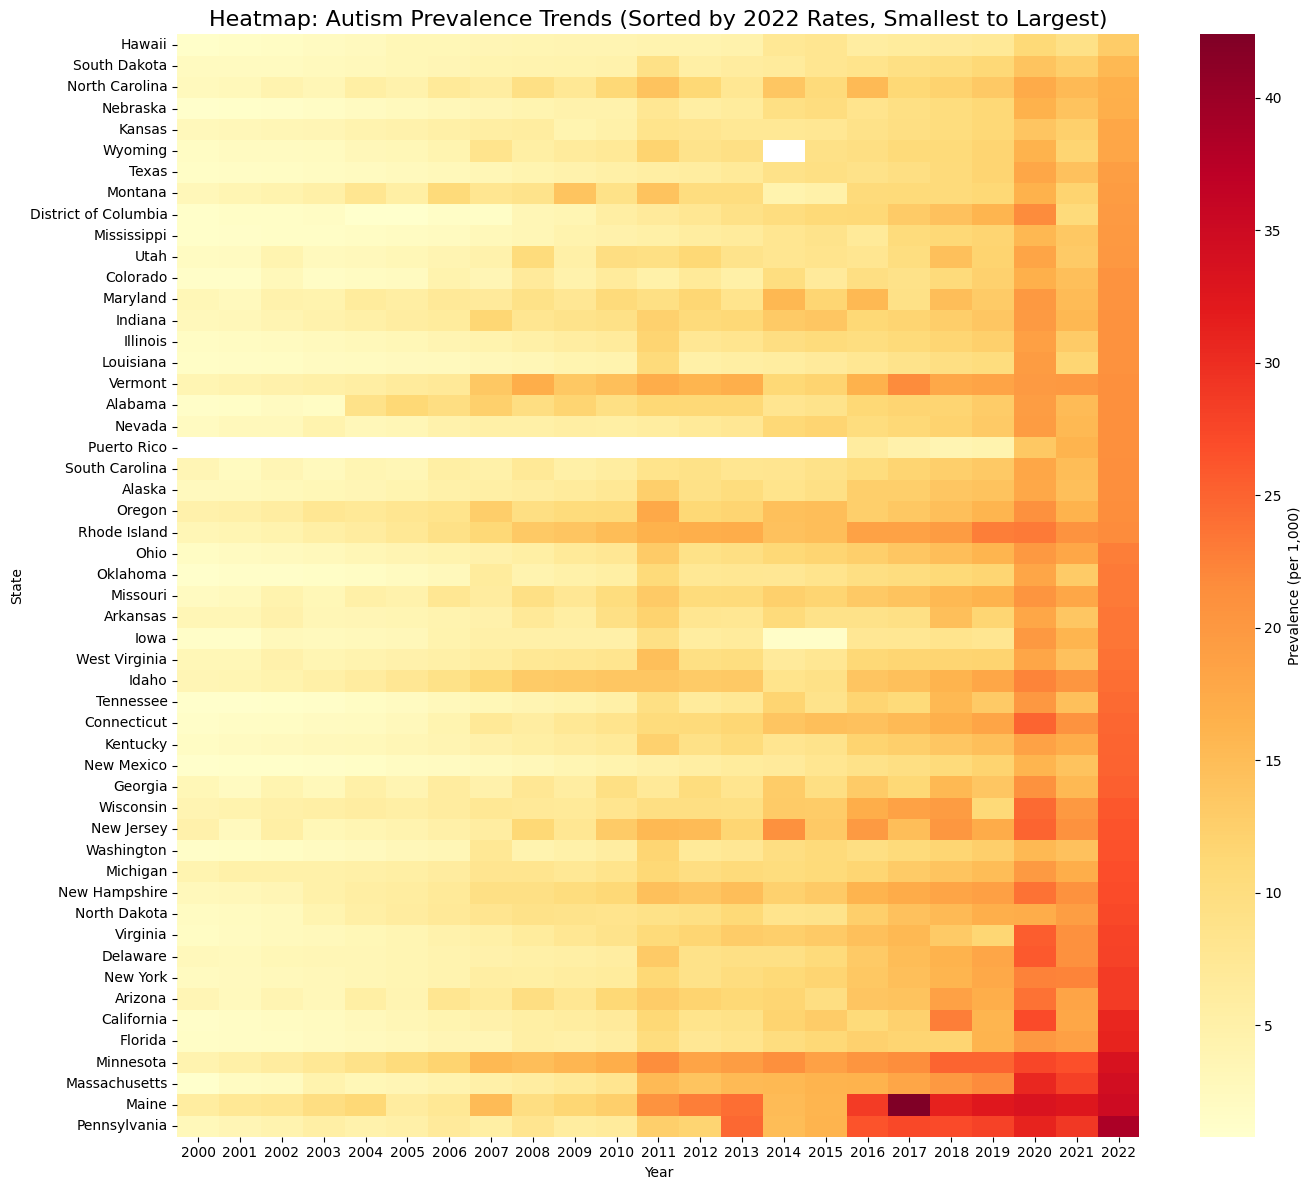

In [23]:
df_clean = df[df['State'] != 'Total']

# Create a pivot table: Rows = State, Columns = Year, Cells = Average Prevalence
pivot_df = df_clean.pivot_table(index='State', columns='Year', values='Prevalence Estimates per 1,000 Children', aggfunc='mean')

# Sort the pivot table by the column '2022' (smallest to largest)
pivot_df_sorted = pivot_df.sort_values(by=2022, ascending=True)

# Create the heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(pivot_df_sorted, cmap='YlOrRd', cbar_kws={'label': 'Prevalence (per 1,000)'})
plt.title('Heatmap: Autism Prevalence Trends (Sorted by 2022 Rates, Smallest to Largest)', fontsize=16)
plt.ylabel('State')
plt.xlabel('Year')
plt.tight_layout()

# Save the plot
plt.savefig('autism_heatmap_sorted_2022.png')
plt.show()

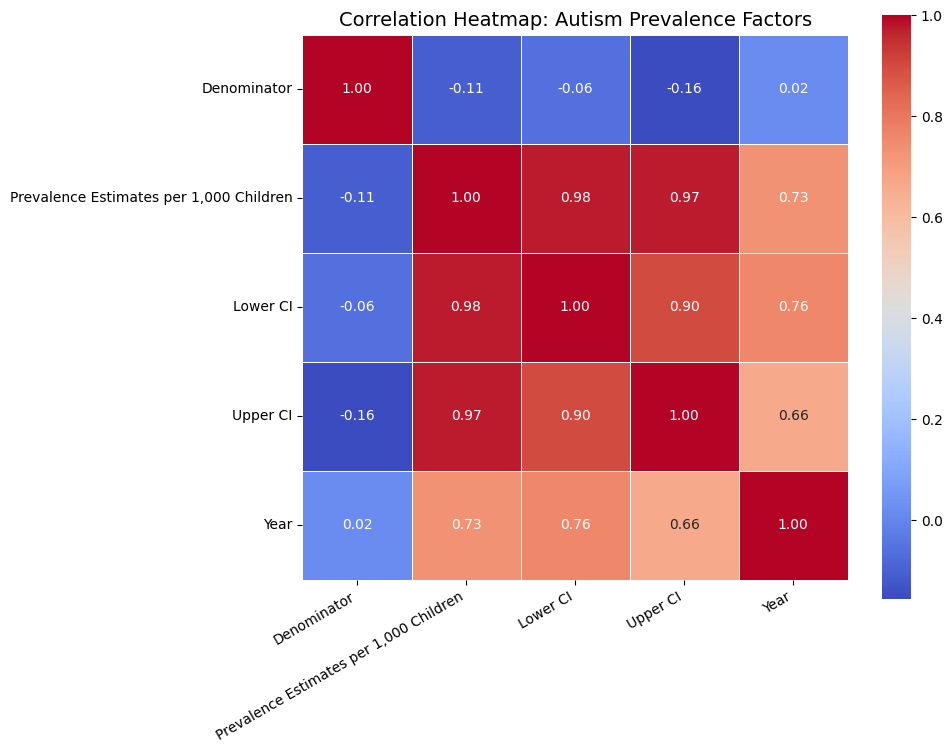

In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load and Clean
df = pd.read_csv('autism.csv')
df_clean = df[df['State'] != 'Total'].copy()

# 2. Ensure Numeric Data
numeric_cols = ['Denominator', 'Prevalence Estimates per 1,000 Children', 
                'Lower CI', 'Upper CI', 'Year']
for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# 3. Calculate Correlation
corr_matrix = df_clean[numeric_cols].corr()

# 4. Create Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, square=True)

# --- KEY CHANGE: ROTATE XTICKS ---
# rotation=45: Tilts the text
# ha='right': Aligns the end of the text string with the tick mark
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.title('Correlation Heatmap: Autism Prevalence Factors', fontsize=14)
plt.tight_layout()

# 5. Save and Show
plt.savefig('autism_heatmap_rotated.png')
plt.show()

## Regression

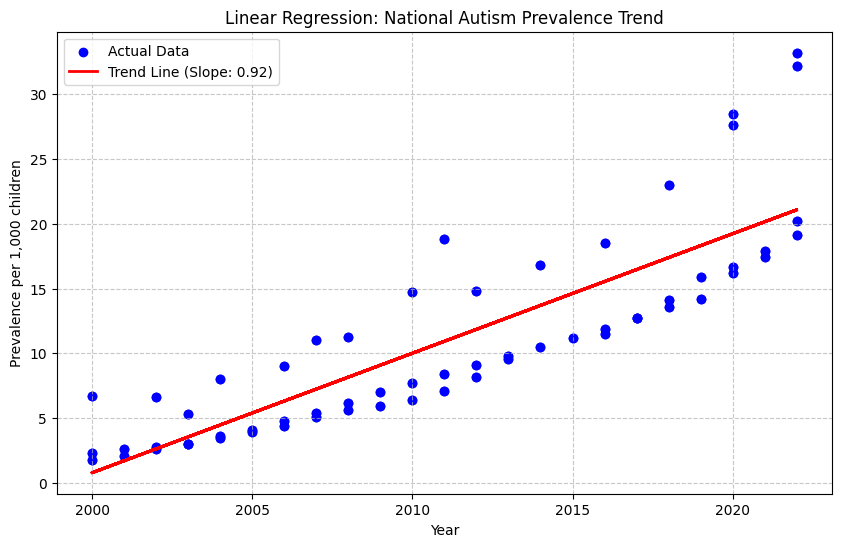

Average annual increase: 0.92 children per 1,000


In [33]:
from sklearn.linear_model import LinearRegression
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load a fresh copy so 'Total' is back
df_original = pd.read_csv('autism.csv')

# 2. Filter for 'Total'
df_total = df_original[df_original['State'] == 'Total'].dropna(subset=['Prevalence Estimates per 1,000 Children', 'Year'])

# 3. Now the rest of your code will work!
X = df_total[['Year']].values
y = df_total['Prevalence Estimates per 1,000 Children'].values

model = LinearRegression()
model.fit(X, y)

# Create and fit the model
model = LinearRegression()
model.fit(X, y)

# Predictions for plotting
y_pred = model.predict(X)

# Visualize the trend
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, y_pred, color='red', linewidth=2, label=f'Trend Line (Slope: {model.coef_[0]:.2f})')
plt.title('Linear Regression: National Autism Prevalence Trend')
plt.xlabel('Year')
plt.ylabel('Prevalence per 1,000 children')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.savefig('autism_linear_regression.png')
plt.show()

print(f"Average annual increase: {model.coef_[0]:.2f} children per 1,000")

Best Alpha found by Cross-Validation: 10.0000
Root Mean Squared Error (RMSE): 3.9077
R-squared Score (R2): 0.7879


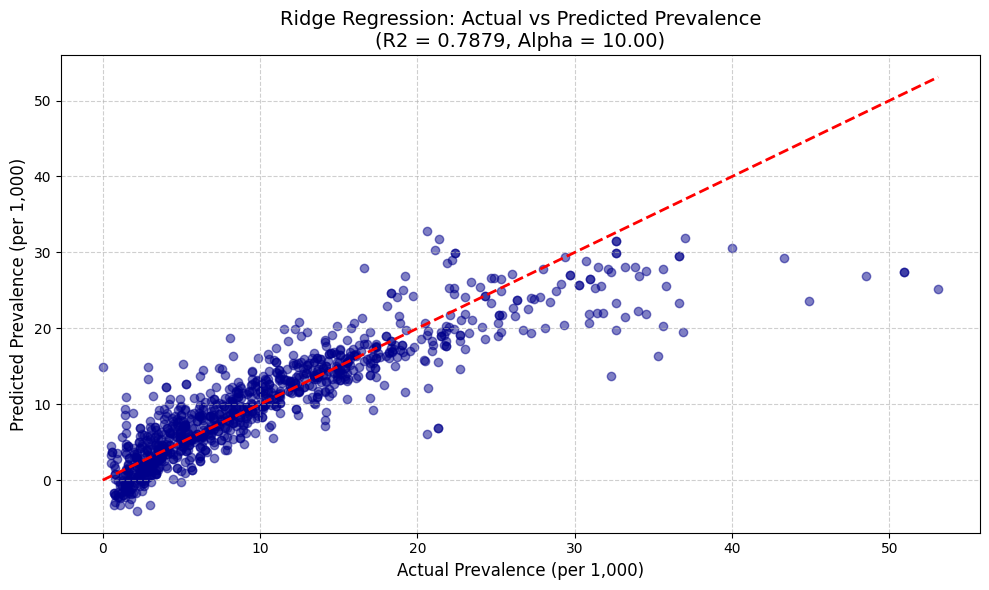

In [30]:
df = pd.read_csv('autism.csv')

# Preprocessing: Remove "Total" summary rows to focus on state-level data
df_clean = df[df['State'] != 'Total'].dropna(subset=['Prevalence Estimates per 1,000 Children', 'Year'])

# Feature engineering: Encode categorical variables (State and Data Set)
# We use drop_first=True to avoid the dummy variable trap
X = pd.get_dummies(df_clean[['Year', 'State', 'Data Set']], drop_first=True)
y = df_clean['Prevalence Estimates per 1,000 Children']

# Feature scaling (Standardization) is required for Ridge regression
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Initialize and train Ridge regression with built-in Cross-Validation to find best alpha
# We test a range of alpha values from 0.001 to 1000
ridge_model = RidgeCV(alphas=np.logspace(-3, 3, 10))
ridge_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = ridge_model.predict(X_test)

# Evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
best_alpha = ridge_model.alpha_

print(f"Best Alpha found by Cross-Validation: {best_alpha:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared Score (R2): {r2:.4f}")

# Visualization: Actual vs Predicted Prevalence
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='darkblue')
# Add a 45-degree reference line
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', lw=2)
plt.title(f'Ridge Regression: Actual vs Predicted Prevalence\n(R2 = {r2:.4f}, Alpha = {best_alpha:.2f})', fontsize=14)
plt.xlabel('Actual Prevalence (per 1,000)', fontsize=12)
plt.ylabel('Predicted Prevalence (per 1,000)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Save the plot
plt.savefig('autism_ridge_regression.png')
plt.show()

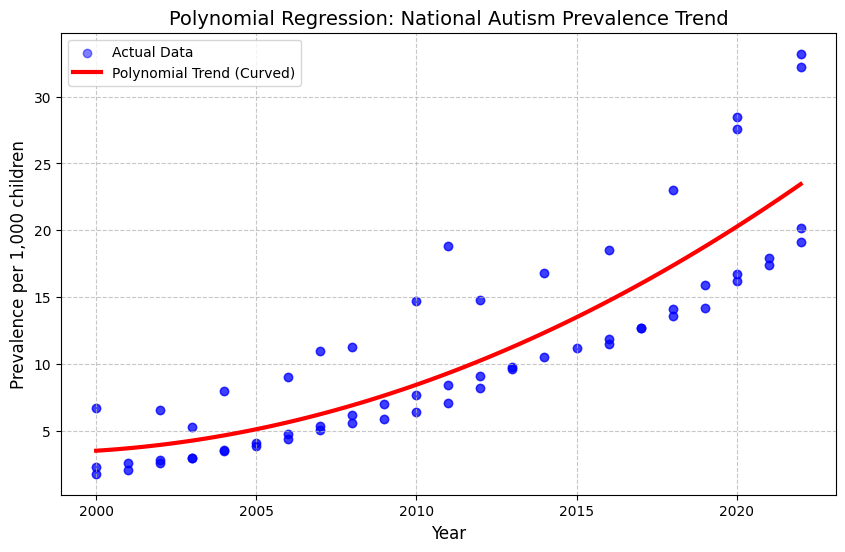

Polynomial R² score: 0.7522


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# 1. Load a fresh copy of the data
df = pd.read_csv('autism.csv')

# 2. Get the National trend (either from 'Total' or by averaging all states)
df_total = df[df['State'] == 'Total'].dropna(subset=['Prevalence Estimates per 1,000 Children', 'Year'])

if df_total.empty:
    # If 'Total' was removed earlier, average the states by year instead
    print("No 'Total' rows found; calculating national average from states...")
    df_total = df[df['State'] != 'Total'].groupby('Year')['Prevalence Estimates per 1,000 Children'].mean().reset_index()

# 3. Prepare variables and ensure they are numeric (floats/ints)
X = df_total[['Year']].values.astype(float)
y = df_total['Prevalence Estimates per 1,000 Children'].values.astype(float)

# 4. Polynomial Regression (Degree 2 - creates a curve)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

poly_model = LinearRegression()
poly_model.fit(X_poly, y)

# 5. Create a smooth line for plotting
X_smooth = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_smooth = poly_model.predict(poly.transform(X_smooth))

# 6. Visualize
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', alpha=0.5, label='Actual Data')
plt.plot(X_smooth, y_smooth, color='red', linewidth=3, label='Polynomial Trend (Curved)')
plt.title('Polynomial Regression: National Autism Prevalence Trend', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Prevalence per 1,000 children', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('autism_polynomial_regression.png')
plt.show()



print(f"Polynomial R² score: {poly_model.score(X_poly, y):.4f}")